# Team 14 — End-To-End Pipeline Project (Track B)

**Course:** INST 447 — Data Sources and Manipulation  
**Team Members:** Kyle Tabong · Taylor Hardesty · Ashrutha Lingampalli  
**Track:** B — End-to-End Pipeline

---

## Project Overview

This notebook documents our full data pipeline for answering the following research question:

> **What economic trends were observed from 2000 to 2023, and how did changes in U.S. trade impact broader macroeconomic conditions?**

We pull data programmatically from two public APIs (FRED and World Bank), clean and merge it into a single annual dataset, run correlation and regression analysis, and visualize key trends.

### Data Sources
- **FRED API** (Federal Reserve Bank of St. Louis): Real GDP (`GDPC1`), CPI (`CPIAUCSL`), Trade Balance (`BOPGTB`)
- **World Bank API**: U.S. trade as a percentage of GDP (`NE.TRD.GNFS.ZS`)

### Note on Date Range
The World Bank data starts at 2002, so the final merged dataset covers **2002–2023** (22 years), even though FRED data was pulled starting from 2000.

---


## Section 1: Environment Setup

Install required libraries and verify the environment is ready before pulling any data.

In [28]:
pip install fredapi wbgapi pandas scipy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [29]:
from fredapi import Fred
import wbgapi as wb
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as p

fred = Fred(api_key='a9713eaadd48f6245b56b5828e93669a')
print("Environment is Ready!")

Environment is Ready!


## Section 2: Data Ingestion

We pull four datasets directly from their respective APIs and save them as CSV files for reproducibility.

- **GDP (GDPC1):** Quarterly real GDP in billions of chained 2017 dollars
- **CPI (CPIAUCSL):** Monthly consumer price index, used to track inflation
- **Trade Balance (BOPGTB):** Monthly U.S. goods trade balance in millions of dollars (negative = deficit)
- **World Bank Trade (NE.TRD.GNFS.ZS):** Annual U.S. trade as a percentage of GDP


### Pull GDP Data

In [30]:
gdp = fred.get_series('GDPC1', observation_start='2000-01-01', observation_end='2023-12-31')
gdp_df = gdp.reset_index()
gdp_df.columns = ['date', 'gdp']
print(f"GDP: {len(gdp_df)} rows | {gdp_df['date'].min().date()} to {gdp_df['date'].max().date()}")
gdp_df.head()

GDP: 96 rows | 2000-01-01 to 2023-10-01


,date,gdp
0,2000-01-01,13878.147
1,2000-04-01,14130.908
2,2000-07-01,14145.312
3,2000-10-01,14229.765
4,2001-01-01,14183.120


### Pull CPI Data

In [31]:
cpi = fred.get_series('CPIAUCSL', observation_start='2000-01-01', observation_end='2023-12-31')
cpi_df = cpi.reset_index()
cpi_df.columns = ['date', 'cpi']
print(f"CPI: {len(cpi_df)} rows | {cpi_df['date'].min().date()} to {cpi_df['date'].max().date()}")
cpi_df.head()

CPI: 288 rows | 2000-01-01 to 2023-12-01


,date,cpi
0,2000-01-01,169.3
1,2000-02-01,170.0
2,2000-03-01,171.0
3,2000-04-01,170.9
4,2000-05-01,171.2


### Pull Trade Balance Data

In [32]:
trade_balance = fred.get_series('BOPGTB', observation_start='2000-01-01', observation_end='2023-12-31')
trade_df = trade_balance.reset_index()
trade_df.columns = ['date', 'trade_balance']
print(f"Trade Balance: {len(trade_df)} rows | {trade_df['date'].min().date()} to {trade_df['date'].max().date()}")
trade_df.head()

Trade Balance: 288 rows | 2000-01-01 to 2023-12-01


,date,trade_balance
0,2000-01-01,-33360.0
1,2000-02-01,-36214.0
2,2000-03-01,-37326.0
3,2000-04-01,-35671.0
4,2000-05-01,-35883.0


### Pull World Bank Trade Data

In [33]:
trade_wb = wb.data.DataFrame('NE.TRD.GNFS.ZS', 'USA', mrv=23)
print(f"World Bank: {trade_wb.shape[1]} years of data")
trade_wb.head()

World Bank: 23 years of data


,YR2002,YR2003,YR2004,YR2005,YR2006,YR2007,YR2008,YR2009,YR2010,YR2011,...,YR2015,YR2016,YR2017,YR2018,YR2019,YR2020,YR2021,YR2022,YR2023,YR2024
economy,,,,,,,,,,,,,,,,,,,,,
USA,22.286374,22.627313,24.448062,25.638553,26.975278,28.012018,29.867796,24.759531,28.219895,30.842486,...,27.823565,26.607962,27.313021,27.610379,26.453759,23.401563,25.609558,27.31394,25.29033,25.378634


### Save Raw Data to CSV

In [34]:
gdp_df.to_csv('gdp_data.csv', index=False)
cpi_df.to_csv('cpi_data.csv', index=False)
trade_df.to_csv('trade_balance_data.csv', index=False)
trade_wb.to_csv('world_bank_trade.csv')
print("All files saved!")

All files saved!


## Section 3: Data Cleaning & Merging

Each dataset arrives at a different frequency:
- CPI and Trade Balance are **monthly**
- GDP is **quarterly**
- World Bank data is already **annual**

We aggregate CPI and Trade Balance to annual averages, and average GDP across the four quarters per year. We also derive inflation rate (year-over-year CPI % change) and GDP growth rate (year-over-year GDP % change) as additional columns.


### Clean CPI Data (Monthly → Annual)

In [35]:
cpi_df['date'] = pd.to_datetime(cpi_df['date'])
cpi_df['year'] = cpi_df['date'].dt.year
cpi_df = cpi_df.dropna(subset=['cpi'])

cpi_annual = (
    cpi_df.groupby('year')['cpi']
    .mean()
    .round(3)
    .reset_index()
    .rename(columns={'cpi': 'cpi_avg'})
)

# Year-over-year inflation rate (%)
cpi_annual['inflation_rate_pct'] = (cpi_annual['cpi_avg'].pct_change() * 100).round(3)

print(f"CPI cleaned: {cpi_annual['year'].min()}–{cpi_annual['year'].max()} ({len(cpi_annual)} rows)")
cpi_annual.head()

CPI cleaned: 2000–2023 (24 rows)


,year,cpi_avg,inflation_rate_pct
0,2000,172.192,NaN
1,2001,177.042,2.817
2,2002,179.867,1.596
3,2003,184.000,2.298
4,2004,188.908,2.667


### Clean GDP Data (Quarterly → Annual)

In [36]:
gdp_df['date'] = pd.to_datetime(gdp_df['date'])
gdp_df['year'] = gdp_df['date'].dt.year
gdp_df = gdp_df.dropna(subset=['gdp'])

gdp_annual = (
    gdp_df.groupby('year')['gdp']
    .mean()
    .round(3)
    .reset_index()
    .rename(columns={'gdp': 'gdp_avg_billions'})
)

# Year-over-year GDP growth rate (%)
gdp_annual['gdp_growth_rate_pct'] = (gdp_annual['gdp_avg_billions'].pct_change() * 100).round(3)

print(f"GDP cleaned: {gdp_annual['year'].min()}–{gdp_annual['year'].max()} ({len(gdp_annual)} rows)")
gdp_annual.head()

GDP cleaned: 2000–2023 (24 rows)


,year,gdp_avg_billions,gdp_growth_rate_pct
0,2000,14096.033,NaN
1,2001,14230.726,0.956
2,2002,14472.712,1.700
3,2003,14877.312,2.796
4,2004,15449.757,3.848


### Clean Trade Balance Data (Monthly → Annual)

In [37]:
trade_df['date'] = pd.to_datetime(trade_df['date'])
trade_df['year'] = trade_df['date'].dt.year
trade_df = trade_df.dropna(subset=['trade_balance'])

trade_annual = (
    trade_df.groupby('year')['trade_balance']
    .mean()
    .round(3)
    .reset_index()
    .rename(columns={'trade_balance': 'trade_balance_avg_millions'})
)

print(f"Trade Balance cleaned: {trade_annual['year'].min()}–{trade_annual['year'].max()} ({len(trade_annual)} rows)")
trade_annual.head()

Trade Balance cleaned: 2000–2023 (24 rows)


,year,trade_balance_avg_millions
0,2000,-37231.750
1,2001,-35197.500
2,2002,-39603.667
3,2003,-45136.917
4,2004,-55397.167


### Clean World Bank Data (Wide → Long Format)

In [38]:
wb_df = pd.read_csv('world_bank_trade.csv')
wb_df.columns = wb_df.columns.str.strip().str.lower()

wb_melted = wb_df.melt(
    id_vars=['economy'],
    var_name='year_str',
    value_name='trade_pct_gdp'
)

wb_melted['year'] = wb_melted['year_str'].str.extract(r'(\d{4})').astype(int)
wb_melted['trade_pct_gdp'] = wb_melted['trade_pct_gdp'].round(3)

wb_annual = (
    wb_melted[['year', 'trade_pct_gdp']]
    .dropna(subset=['trade_pct_gdp'])
    .sort_values('year')
    .reset_index(drop=True)
)

print(f"World Bank cleaned: {wb_annual['year'].min()}–{wb_annual['year'].max()} ({len(wb_annual)} rows)")
wb_annual.head()

World Bank cleaned: 2002–2024 (23 rows)


,year,trade_pct_gdp
0,2002,22.286
1,2003,22.627
2,2004,24.448
3,2005,25.639
4,2006,26.975


### Merge All Datasets on Year

In [39]:
merged_df = cpi_annual.merge(gdp_annual, on='year', how='inner')
merged_df = merged_df.merge(trade_annual, on='year', how='inner')
merged_df = merged_df.merge(wb_annual, on='year', how='inner')

merged_df = merged_df[(merged_df['year'] >= 2000) & (merged_df['year'] <= 2023)]
merged_df = merged_df.sort_values('year').reset_index(drop=True)

print(f"Merged dataset shape: {merged_df.shape}")
print(f"Years covered: {merged_df['year'].min()}–{merged_df['year'].max()}")
print(f"Columns: {list(merged_df.columns)}")
merged_df.head()

Merged dataset shape: (22, 7)
Years covered: 2002–2023
Columns: ['year', 'cpi_avg', 'inflation_rate_pct', 'gdp_avg_billions', 'gdp_growth_rate_pct', 'trade_balance_avg_millions', 'trade_pct_gdp']


,year,cpi_avg,inflation_rate_pct,gdp_avg_billions,gdp_growth_rate_pct,trade_balance_avg_millions,trade_pct_gdp
0,2002,179.867,1.596,14472.712,1.700,-39603.667,22.286
1,2003,184.000,2.298,14877.312,2.796,-45136.917,22.627
2,2004,188.908,2.667,15449.757,3.848,-55397.167,24.448
3,2005,195.267,3.366,15987.958,3.484,-65233.500,25.639
4,2006,201.558,3.222,16433.148,2.785,-69774.000,26.975


### Validate Merged Data

Check that the merged dataset has no missing values before proceeding to analysis.

In [40]:
print("── Null Check ──────────────────────────────")
print(merged_df.isnull().sum())
print()
print("── Data Types ──────────────────────────────")
print(merged_df.dtypes)

── Null Check ──────────────────────────────
year                          0
cpi_avg                       0
inflation_rate_pct            0
gdp_avg_billions              0
gdp_growth_rate_pct           0
trade_balance_avg_millions    0
trade_pct_gdp                 0
dtype: int64

── Data Types ──────────────────────────────
year                            int32
cpi_avg                       float64
inflation_rate_pct            float64
gdp_avg_billions              float64
gdp_growth_rate_pct           float64
trade_balance_avg_millions    float64
trade_pct_gdp                 float64
dtype: object


### Save Merged Dataset to CSV

In [41]:
merged_df.to_csv('merged_macro_data.csv', index=False)
print("Merged dataset saved to: merged_macro_data.csv")
print(f"Final shape: {merged_df.shape}")
print(f"Columns: {list(merged_df.columns)}") 

Merged dataset saved to: merged_macro_data.csv
Final shape: (22, 7)
Columns: ['year', 'cpi_avg', 'inflation_rate_pct', 'gdp_avg_billions', 'gdp_growth_rate_pct', 'trade_balance_avg_millions', 'trade_pct_gdp']


## Section 4: Formal Analysis

We run four types of analysis on the merged dataset:

1. **Pearson Correlation Matrix** — measures linear relationships between all variables
2. **Year-over-Year Percentage Changes** — tracks how each variable moved annually
3. **Linear Regression** — tests how well trade balance predicts each macroeconomic variable
4. **One-Way ANOVA** — tests whether trade balance differs significantly across three time periods (2002–2009, 2010–2019, 2020–2023)


### Correlation Analysis — Trade Balance vs All Variables

Pearson correlation ranges from -1 (perfect negative) to +1 (perfect positive). Values close to 0 indicate little to no linear relationship.

In [42]:
corr_cols = [
    'trade_balance_avg_millions',
    'gdp_avg_billions',
    'gdp_growth_rate_pct',
    'cpi_avg',
    'inflation_rate_pct',
    'trade_pct_gdp'
]

corr_matrix = merged_df[corr_cols].corr().round(3)

print("── Pearson Correlation Matrix ──────────────────────────")
print(corr_matrix)

print("\n── Correlations with Trade Balance (sorted) ────────────")
print(corr_matrix['trade_balance_avg_millions'].drop('trade_balance_avg_millions').sort_values())

── Pearson Correlation Matrix ──────────────────────────
                            trade_balance_avg_millions  gdp_avg_billions  \
trade_balance_avg_millions                       1.000            -0.846   
gdp_avg_billions                                -0.846             1.000   
gdp_growth_rate_pct                             -0.312             0.170   
cpi_avg                                         -0.819             0.980   
inflation_rate_pct                              -0.725             0.385   
trade_pct_gdp                                   -0.173             0.102   

                            gdp_growth_rate_pct  cpi_avg  inflation_rate_pct  \
trade_balance_avg_millions               -0.312   -0.819              -0.725   
gdp_avg_billions                          0.170    0.980               0.385   
gdp_growth_rate_pct                       1.000    0.097               0.411   
cpi_avg                                   0.097    1.000               0.399   
inflation_

### Time-Series Analysis — Year-over-Year Percentage Changes

Tracking annual percentage changes helps identify which years saw the most significant shifts in trade and economic conditions.

In [43]:
pct_change_cols = ['trade_balance_avg_millions', 'gdp_avg_billions', 'cpi_avg', 'trade_pct_gdp']
pct_df = merged_df[['year'] + pct_change_cols].copy()

for col in pct_change_cols:
    pct_df[f'{col}_pct_chg'] = pct_df[col].pct_change().mul(100).round(3)

print("── Year-over-Year Percentage Changes ───────────────────")
display_cols = ['year'] + [f'{c}_pct_chg' for c in pct_change_cols]
print(pct_df[display_cols].to_string(index=False))

print("\n── Summary Statistics of Annual % Changes ──────────────")
print(pct_df[[f'{c}_pct_chg' for c in pct_change_cols]].describe().round(3))

── Year-over-Year Percentage Changes ───────────────────
 year  trade_balance_avg_millions_pct_chg  gdp_avg_billions_pct_chg  cpi_avg_pct_chg  trade_pct_gdp_pct_chg
 2002                                 NaN                       NaN              NaN                    NaN
 2003                              13.972                     2.796            2.298                  1.530
 2004                              22.731                     3.848            2.667                  8.048
 2005                              17.756                     3.484            3.366                  4.872
 2006                               6.960                     2.785            3.222                  5.211
 2007                              -1.922                     2.004            2.871                  3.844
 2008                               1.376                     0.114            3.815                  6.626
 2009                             -38.775                    -2.577           -

### Linear Regression — Trade Balance vs Key Variables

We run a simple linear regression to quantify how strongly trade balance predicts each macroeconomic variable. R² tells us what proportion of the variance in each variable is explained by trade balance.

In [44]:
reg_df = merged_df.dropna(subset=['gdp_growth_rate_pct', 'inflation_rate_pct']).copy()

targets = [
    ('gdp_avg_billions',    'GDP (Billions USD)'),
    ('gdp_growth_rate_pct', 'GDP Growth Rate (%)'),
    ('inflation_rate_pct',  'Inflation Rate (%)'),
    ('trade_pct_gdp',       'Trade as % of GDP'),
]

print("── Regression Results: Trade Balance → Each Variable ───")

for target_col, target_label in targets:
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        reg_df['trade_balance_avg_millions'], reg_df[target_col]
    )
    r2 = r_value ** 2
    sig = '*** significant (p < 0.05)' if p_value < 0.05 else 'not significant'

    print(f"\nTrade Balance → {target_label}")
    print(f"  Coefficient : {slope:.5f}")
    print(f"  Intercept   : {intercept:.3f}")
    print(f"  R²          : {r2:.4f}")
    print(f"  p-value     : {p_value:.4f}  ({sig})")

── Regression Results: Trade Balance → Each Variable ───

Trade Balance → GDP (Billions USD)
  Coefficient : -0.13816
  Intercept   : 9096.549
  R²          : 0.7165
  p-value     : 0.0000  (*** significant (p < 0.05))

Trade Balance → GDP Growth Rate (%)
  Coefficient : -0.00004
  Intercept   : -0.409
  R²          : 0.0971
  p-value     : 0.1581  (not significant)

Trade Balance → Inflation Rate (%)
  Coefficient : -0.00009
  Intercept   : -3.157
  R²          : 0.5261
  p-value     : 0.0001  (*** significant (p < 0.05))

Trade Balance → Trade as % of GDP
  Coefficient : -0.00003
  Intercept   : 24.937
  R²          : 0.0298
  p-value     : 0.4420  (not significant)


### ANOVA Test — Trade Deficit Across Time Periods

We divide the dataset into three periods and test whether the average trade balance differs significantly between them. A p-value below 0.05 means the differences are statistically significant.

In [45]:
def assign_period(year):
    if year < 2010:
        return '2002-2009'
    elif year < 2020:
        return '2010-2019'
    else:
        return '2020-2023'

merged_df['period'] = merged_df['year'].apply(assign_period)

groups = [
    merged_df.loc[merged_df['period'] == p, 'trade_balance_avg_millions'].values
    for p in ['2002-2009', '2010-2019', '2020-2023']
]

f_stat, p_value = stats.f_oneway(*groups)

print("── One-Way ANOVA: Trade Balance by Period ──────────────")
print(f"  F-statistic : {f_stat:.4f}")
print(f"  p-value     : {p_value:.4f}")
if p_value < 0.05:
    print("  Result      : Statistically significant difference across periods (p < 0.05)")
else:
    print("  Result      : No statistically significant difference across periods (p >= 0.05)")

print("\n── Mean Trade Balance by Period ────────────────────────")
print(merged_df.groupby('period')['trade_balance_avg_millions'].mean().round(3))

── One-Way ANOVA: Trade Balance by Period ──────────────
  F-statistic : 14.8285
  p-value     : 0.0001
  Result      : Statistically significant difference across periods (p < 0.05)

── Mean Trade Balance by Period ────────────────────────
period
2002-2009   -56928.386
2010-2019   -63568.917
2020-2023   -88085.980
Name: trade_balance_avg_millions, dtype: float64


### Summary Statistics — Comparing Means Across Periods

Breaking down mean values across the three time periods helps contextualize how the broader economy shifted alongside trade patterns.

In [46]:
summary_cols = [
    'trade_balance_avg_millions',
    'gdp_avg_billions',
    'gdp_growth_rate_pct',
    'cpi_avg',
    'inflation_rate_pct',
    'trade_pct_gdp'
]

print("── Mean Values by Period ───────────────────────────────")
period_means = (
    merged_df.groupby('period')[summary_cols]
    .mean()
    .round(3)
    .reindex(['2002-2009', '2010-2019', '2020-2023'])
)
print(period_means.T.to_string())

print("\n── Overall Descriptive Statistics (2002–2023) ──────────")
print(merged_df[summary_cols].describe().round(3))

── Mean Values by Period ───────────────────────────────
period                      2002-2009  2010-2019  2020-2023
trade_balance_avg_millions -56928.386 -63568.917 -88085.980
gdp_avg_billions            15889.241  18582.176  21654.139
gdp_growth_rate_pct             1.769      2.396      2.382
cpi_avg                       198.345    237.113    281.790
inflation_rate_pct              2.439      1.770      4.513
trade_pct_gdp                  25.577     28.556     25.404

── Overall Descriptive Statistics (2002–2023) ──────────
       trade_balance_avg_millions  gdp_avg_billions  gdp_growth_rate_pct  \
count                      22.000            22.000               22.000   
mean                   -65611.826         18161.466                2.166   
std                     14430.216          2355.323                1.817   
min                    -97880.417         14472.712               -2.577   
25%                    -71022.313         16515.472                1.865   
50%      

## Section 5: Visualizations

The charts below visualize the key trends and relationships in the data. Each group of charts is designed to support the analysis from Section 4.


### Line Charts — All Variables Over Time

Shows how each variable trended across the full 2002–2023 period. Notable events like the 2008 financial crisis and the COVID-19 pandemic (2020) should be visible as dips or spikes.

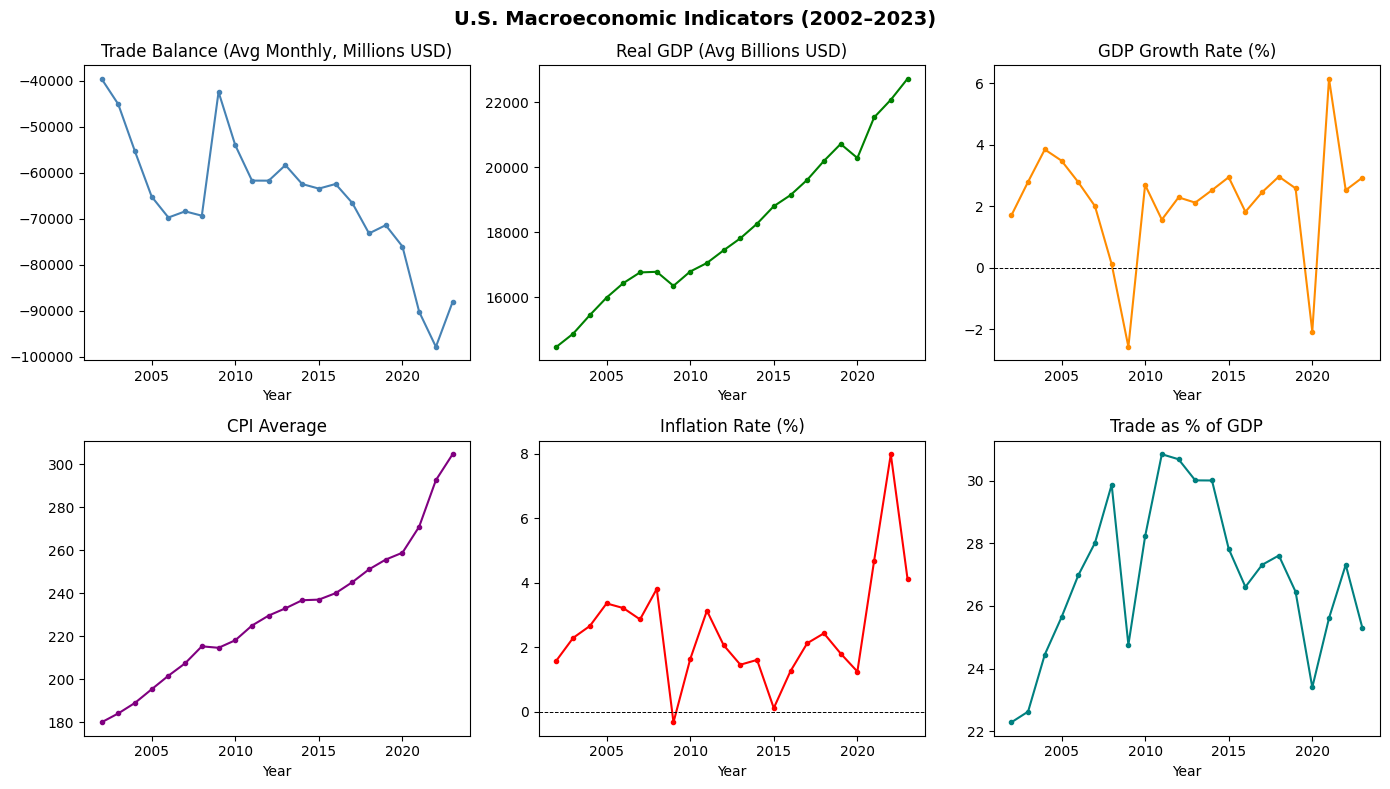

In [47]:
fig, axes = p.subplots(2, 3, figsize=(14, 8))
fig.suptitle('U.S. Macroeconomic Indicators (2002–2023)', fontsize=14, fontweight='bold')

axes[0, 0].plot(merged_df['year'], merged_df['trade_balance_avg_millions'], color='steelblue', marker='o', markersize=3)
axes[0, 0].set_title('Trade Balance (Avg Monthly, Millions USD)')
axes[0, 0].set_xlabel('Year')

axes[0, 1].plot(merged_df['year'], merged_df['gdp_avg_billions'], color='green', marker='o', markersize=3)
axes[0, 1].set_title('Real GDP (Avg Billions USD)')
axes[0, 1].set_xlabel('Year')

axes[0, 2].plot(merged_df['year'], merged_df['gdp_growth_rate_pct'], color='darkorange', marker='o', markersize=3)
axes[0, 2].axhline(0, color='black', linewidth=0.7, linestyle='--')
axes[0, 2].set_title('GDP Growth Rate (%)')
axes[0, 2].set_xlabel('Year')

axes[1, 0].plot(merged_df['year'], merged_df['cpi_avg'], color='purple', marker='o', markersize=3)
axes[1, 0].set_title('CPI Average')
axes[1, 0].set_xlabel('Year')

axes[1, 1].plot(merged_df['year'], merged_df['inflation_rate_pct'], color='red', marker='o', markersize=3)
axes[1, 1].axhline(0, color='black', linewidth=0.7, linestyle='--')
axes[1, 1].set_title('Inflation Rate (%)')
axes[1, 1].set_xlabel('Year')

axes[1, 2].plot(merged_df['year'], merged_df['trade_pct_gdp'], color='teal', marker='o', markersize=3)
axes[1, 2].set_title('Trade as % of GDP')
axes[1, 2].set_xlabel('Year')

p.tight_layout()
p.show()

### Bar Charts — Period Mean Comparisons

Compares average values across the three defined time periods (2002–2009, 2010–2019, 2020–2023) for each variable.

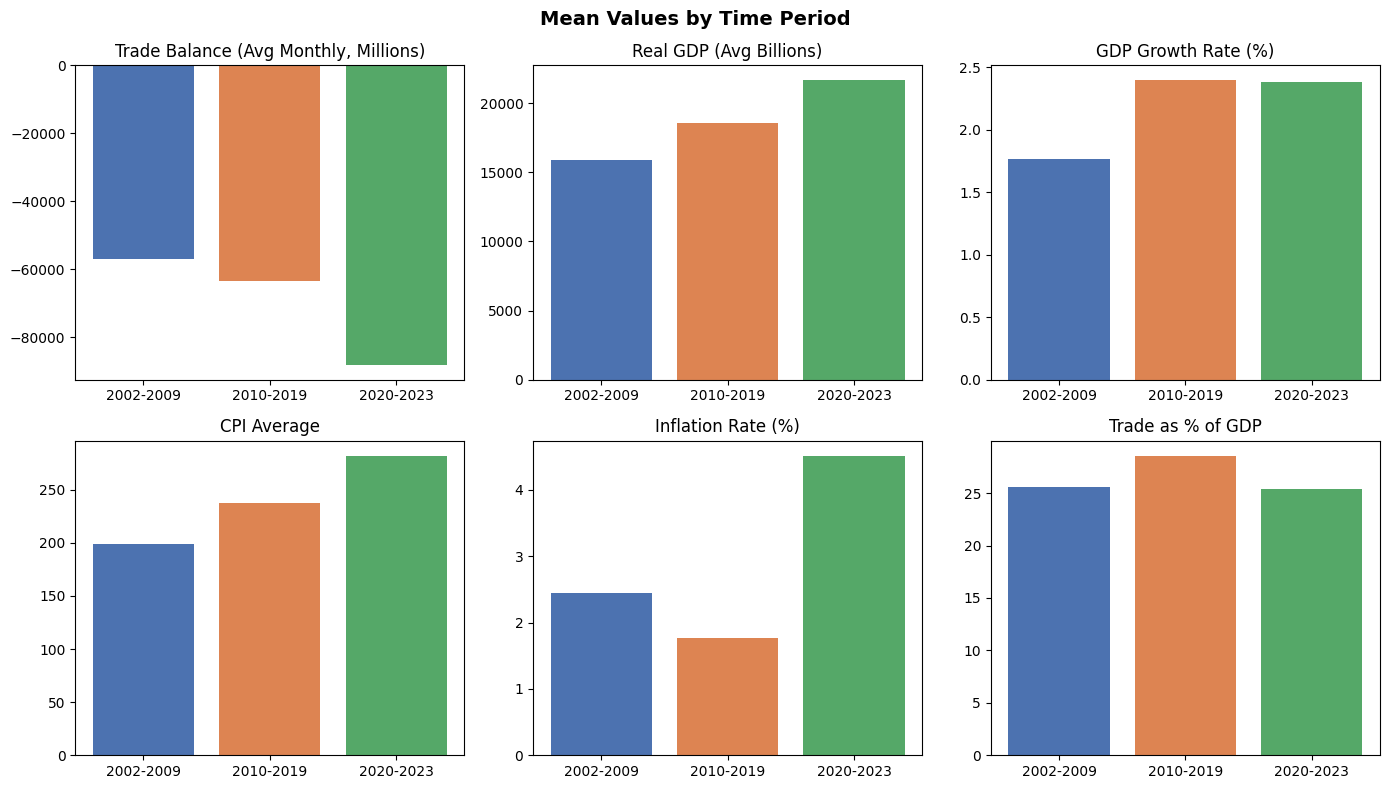

In [48]:
fig, axes = p.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Mean Values by Time Period', fontsize=14, fontweight='bold')

colors = ['#4C72B0', '#DD8452', '#55A868']

axes[0, 0].bar(period_means.index, period_means['trade_balance_avg_millions'], color=colors)
axes[0, 0].set_title('Trade Balance (Avg Monthly, Millions)')

axes[0, 1].bar(period_means.index, period_means['gdp_avg_billions'], color=colors)
axes[0, 1].set_title('Real GDP (Avg Billions)')

axes[0, 2].bar(period_means.index, period_means['gdp_growth_rate_pct'], color=colors)
axes[0, 2].set_title('GDP Growth Rate (%)')

axes[1, 0].bar(period_means.index, period_means['cpi_avg'], color=colors)
axes[1, 0].set_title('CPI Average')

axes[1, 1].bar(period_means.index, period_means['inflation_rate_pct'], color=colors)
axes[1, 1].set_title('Inflation Rate (%)')

axes[1, 2].bar(period_means.index, period_means['trade_pct_gdp'], color=colors)
axes[1, 2].set_title('Trade as % of GDP')

p.tight_layout()
p.show()

### Correlation Matrix Heatmap

Visualizes the Pearson correlation matrix. Blue = negative correlation, red = positive correlation. Strong correlations (close to ±1) suggest a meaningful linear relationship between variables.

/var/folders/8x/9m_01vcj3gs40c6zrw5tlxt40000gn/T/ipykernel_36161/3514680516.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  p.tight_layout()


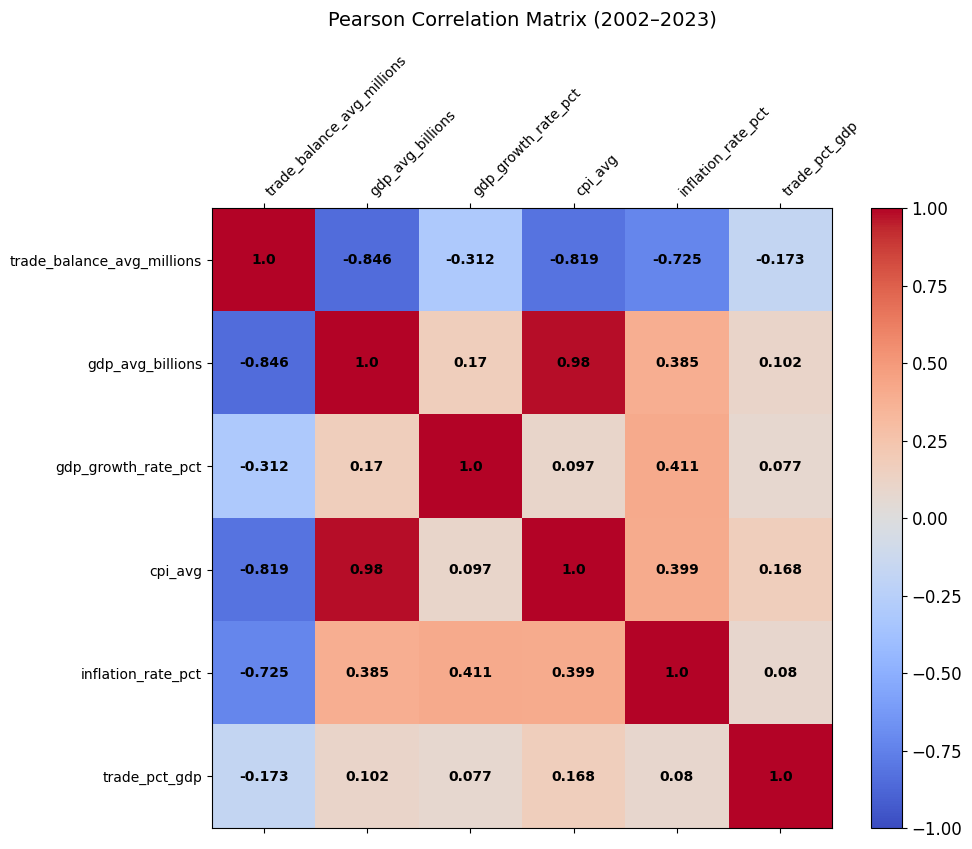

In [49]:
f = p.figure(figsize=(10, 8))
p.matshow(corr_matrix, fignum=f.number, cmap='coolwarm', vmin=-1, vmax=1)
cb = p.colorbar()
cb.ax.tick_params(labelsize=12)
p.title('Pearson Correlation Matrix (2002–2023)', fontsize=14, pad=20)

p.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='left', fontsize=10)
p.yticks(range(len(corr_matrix.columns)), corr_matrix.columns, fontsize=10)

for x in range(len(corr_matrix.columns)):
    for y in range(len(corr_matrix.columns)):
        p.text(y, x, f"{corr_matrix.iloc[x, y]}",
               ha='center', va='center', color='black', fontweight='bold', fontsize=10)

p.tight_layout()
p.show()

### Scatter Plots — Strongest Correlations with Trade Balance

Focuses on the four variables with the strongest correlation to trade balance. Each point represents one year.

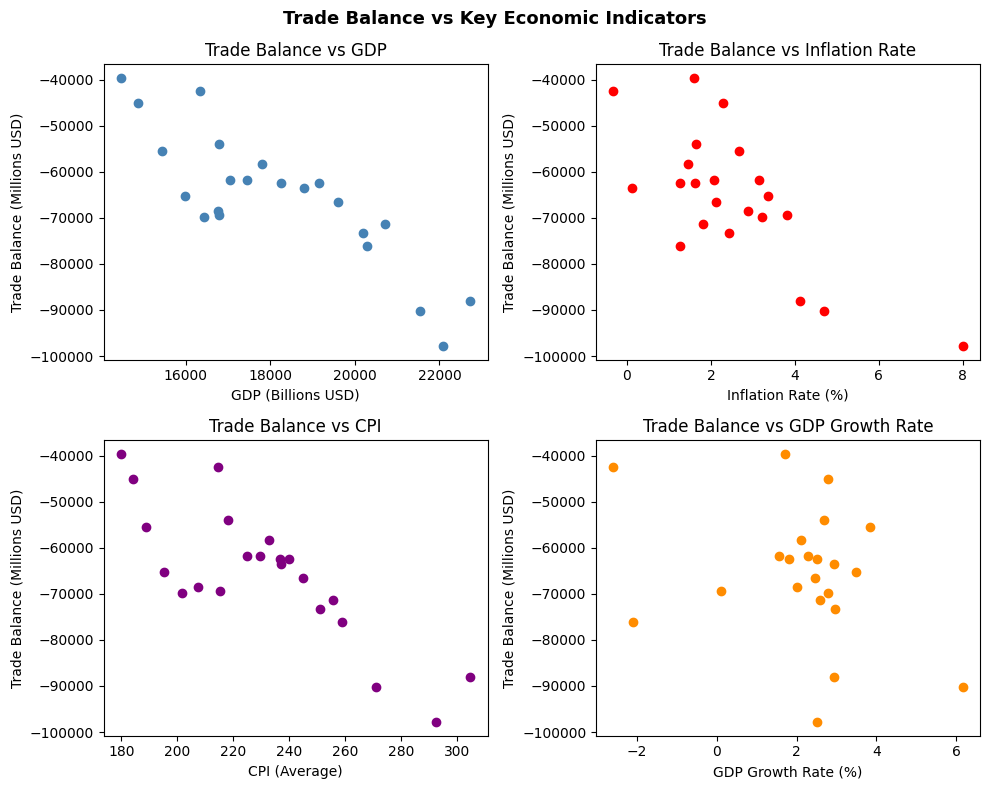

In [50]:
fig, axes = p.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Trade Balance vs Key Economic Indicators', fontsize=13, fontweight='bold')

axes[0, 0].scatter(merged_df['gdp_avg_billions'], merged_df['trade_balance_avg_millions'], color='steelblue')
axes[0, 0].set_title('Trade Balance vs GDP')
axes[0, 0].set_xlabel('GDP (Billions USD)')
axes[0, 0].set_ylabel('Trade Balance (Millions USD)')

axes[0, 1].scatter(merged_df['inflation_rate_pct'], merged_df['trade_balance_avg_millions'], color='red')
axes[0, 1].set_title('Trade Balance vs Inflation Rate')
axes[0, 1].set_xlabel('Inflation Rate (%)')
axes[0, 1].set_ylabel('Trade Balance (Millions USD)')

axes[1, 0].scatter(merged_df['cpi_avg'], merged_df['trade_balance_avg_millions'], color='purple')
axes[1, 0].set_title('Trade Balance vs CPI')
axes[1, 0].set_xlabel('CPI (Average)')
axes[1, 0].set_ylabel('Trade Balance (Millions USD)')

axes[1, 1].scatter(merged_df['gdp_growth_rate_pct'], merged_df['trade_balance_avg_millions'], color='darkorange')
axes[1, 1].set_title('Trade Balance vs GDP Growth Rate')
axes[1, 1].set_xlabel('GDP Growth Rate (%)')
axes[1, 1].set_ylabel('Trade Balance (Millions USD)')

p.tight_layout()
p.show()